# Dropout

---

## 1. Why Do We Use Dropout?

Modern neural networks are highly overparameterized.  
They can easily:

- Memorize training data  
- Overfit noise  
- Rely on fragile neuron interactions  
- Converge to sharp, unstable minima  

Dropout was introduced as a **stochastic regularization technique** to reduce overfitting.

Core idea:

> During training, randomly deactivate neurons so the network cannot rely on specific internal pathways.

Instead of training one deterministic model, we implicitly train a large collection of randomized subnetworks.

---

## 2. Mathematical Definition

Consider a hidden layer:

$$
h = \phi(Wx + b)
$$

Dropout samples a binary mask:

$$
m_i \sim \text{Bernoulli}(p)
$$

where:
- mask
- $p$ = probability of keeping a neuron  
- $1 - p$ = dropout rate  

Using inverted dropout, we define:

$$
\tilde{h}_i = \frac{m_i}{p} h_i
$$

This ensures:

$$
\mathbb{E}[\tilde{h}_i] = h_i
$$

At test time:

- No mask is applied  
- The full network is used  

Thus training is stochastic, inference is deterministic.

---

## 3. Why Dropout Improves Generalization

### 3.1 Breaking Co-Adaptation

Without dropout, neurons may develop **co-dependent features**:

- Feature A only works if Feature B is present  
- Internal representations become fragile  

With dropout:

- Any neuron may disappear  
- Each neuron must be independently useful  

This forces the network to learn robust features.

---

### 3.2 Implicit Ensemble Learning

Each dropout mask defines a subnetwork.
For $n$ neurons, there are $2^n$ possible subnetworks.
Training with dropout approximates minimizing:

$$
\mathbb{E}_m [L(f_m(x))]
$$

At inference, the full network approximates:

$$
\mathbb{E}_m [f_m(x)]
$$

Averaging reduces variance.

---

## 4. Bias–Variance Tradeoff

Generalization error decomposes as:

$$
\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Noise}
$$

Large neural networks:

- Low bias  
- High variance  

Dropout:

- Slightly increases bias (we weaken the model per iteration)  
- Strongly reduces variance (through stochastic averaging)  

Thus:

$$
\text{Variance}_{dropout} < \text{Variance}_{no\ dropout}
$$

Even if:

$$
\text{Bias}_{dropout} > \text{Bias}_{no\ dropout}
$$

Total test error often decreases.

---

## 5. Implicit Normalization Effect

Although Dropout is not an explicit normalization method, it induces **implicit scale control**.

From:

$$
\tilde{h}_i = \frac{m_i}{p} h_i
$$

the variance becomes:

$$
\mathrm{Var}(\tilde{h}_i) = \frac{1-p}{p} h_i^2
$$

Large activations receive larger perturbations.

Thus:

- Large weights become unstable  
- Large activations become risky  
- Optimization discourages excessive magnitude  

Dropout behaves similarly to adaptive regularization.

---

## 6. Geometric Interpretation

Dropout injects multiplicative noise:

$$
\tilde{h} = \frac{m}{p} \odot h
$$

This makes the loss stochastic even for fixed weights.

### Effect on the Loss Landscape

Noise has two important geometric consequences:

1. Sharp minima are unstable.
2. Flat minima are stable.

Sharp minima:

- High curvature  
- Large Hessian eigenvalues  
- Sensitive to perturbations  

Flat minima:

- Low curvature  
- Small Hessian eigenvalues  
- Robust to perturbations  

Dropout pushes optimization toward flatter regions.

Formally, it biases solutions where:

$$
\lambda_{\max}(H) \text{ is small}
$$

This reduces sensitivity and improves generalization.

---

## 7. Optimization Effects

Dropout:

- Increases gradient stochasticity  
- Encourages exploration  
- Slows convergence slightly  
- Reduces overfitting  

It acts as structured noise injection during training.

---

## 8. Example — Dropout and Generalization

Consider fitting:

$$
y = \sin(x) + \epsilon
$$

with a large neural network.

Train two models:

1. Without dropout  
2. With dropout  

### Expected Behavior

Without dropout:

- Very low training loss  
- Overfits noise  
- Highly oscillatory function  
- Large train-test gap  

With dropout:

- Slightly higher training loss  
- Smoother learned function  
- Smaller generalization gap  
- More stable predictions  


In [1]:
1+1

2

In [4]:
import math
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

noise_std = 0.2
batch_size = 128
train_ratio = 0.7
n_samples = 10000

x = (torch.rand(n_samples, 1) * 6 * math.pi) - 3 * math.pi
y = torch.sin(x)

epsilon = noise_std * torch.randn_like(y)
y_noisy = y + epsilon

n_train = int(train_ratio * n_samples)

x_train = x[:n_train]
y_train = y_noisy[:n_train]

x_test = x[n_train:]
y_test = y_noisy[n_train:]

To show the properties first we will create a heavily overparameterized network for a 1D regression (100 neurons accross 50 layers)

In [8]:
class LargeNetNoDropout(nn.Module):
    def __init__(self):
        super().__init__()
        
        layers = []
        input_dim = 1
        hidden_dim = 128
        n_layers = 3
        
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        
        layers.append(nn.Linear(hidden_dim, 1))   
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)


class LargeNetWithDropout(nn.Module):
    def __init__(self, p=0.2):
        super().__init__()
        
        layers = []
        input_dim = 1
        n_layers = 3
        hidden_dim = 128
        
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.Tanh())
        layers.append(nn.Dropout(p))
        
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p))
        
        layers.append(nn.Linear(hidden_dim, 1))
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

In [9]:
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
import torch.optim as optim

def train_model(model, train_loader, test_loader, epochs=100, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for xb, yb in train_loader:
            optimizer.zero_grad()
            
            preds = model(xb)
            loss = criterion(preds, yb)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * xb.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        model.eval()
        test_loss = 0
        
        with torch.no_grad():
            for xb, yb in test_loader:
                preds = model(xb)
                loss = criterion(preds, yb)
                test_loss += loss.item() * xb.size(0)
        
        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}")
    
    return train_losses, test_losses

model_no_dropout = LargeNetNoDropout()
model_dropout = LargeNetWithDropout(p=0.5)

print('Large Net No Dropout:')
train_losses_no, test_losses_no = train_model(model_no_dropout, train_loader, test_loader, epochs=200, lr=1e-3)

print('\nLarge Net With Dropout')
train_losses_do, test_losses_do = train_model(model_dropout, train_loader, test_loader, epochs=200, lr=1e-3)

Large Net No Dropout:
Epoch 0: Train Loss=0.3974, Test Loss=0.2418
Epoch 10: Train Loss=0.0817, Test Loss=0.0825
Epoch 20: Train Loss=0.0497, Test Loss=0.0461
Epoch 30: Train Loss=0.0443, Test Loss=0.0432
Epoch 40: Train Loss=0.0440, Test Loss=0.0442
Epoch 50: Train Loss=0.0454, Test Loss=0.0450
Epoch 60: Train Loss=0.0427, Test Loss=0.0425
Epoch 70: Train Loss=0.0435, Test Loss=0.0431
Epoch 80: Train Loss=0.0431, Test Loss=0.0447
Epoch 90: Train Loss=0.0437, Test Loss=0.0457
Epoch 100: Train Loss=0.0433, Test Loss=0.0416
Epoch 110: Train Loss=0.0439, Test Loss=0.0426
Epoch 120: Train Loss=0.0427, Test Loss=0.0426
Epoch 130: Train Loss=0.0453, Test Loss=0.0429
Epoch 140: Train Loss=0.0423, Test Loss=0.0421
Epoch 150: Train Loss=0.0438, Test Loss=0.0420
Epoch 160: Train Loss=0.0422, Test Loss=0.0436
Epoch 170: Train Loss=0.0433, Test Loss=0.0429
Epoch 180: Train Loss=0.0423, Test Loss=0.0432
Epoch 190: Train Loss=0.0429, Test Loss=0.0417

Large Net With Dropout
Epoch 0: Train Loss=0.542

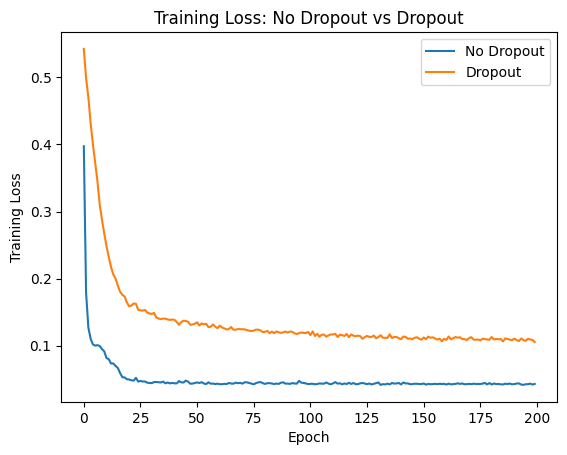

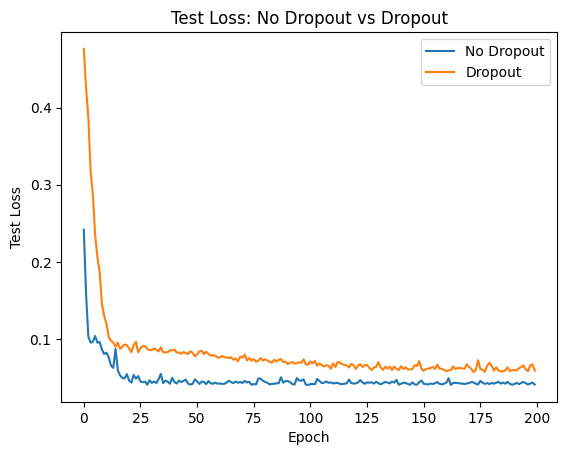

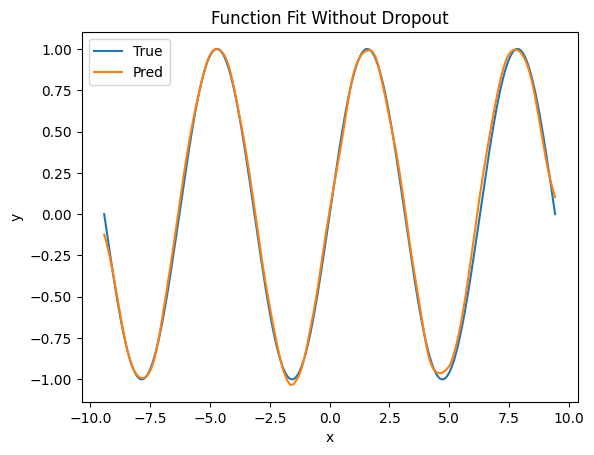

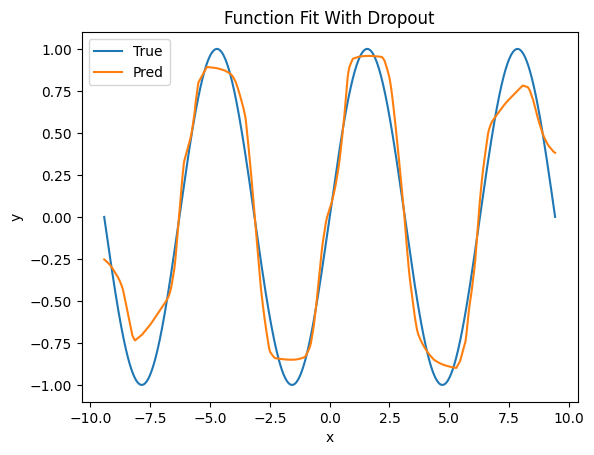

In [13]:
import torch
import matplotlib.pyplot as plt
import math

# ===============================
# 1) Training Loss Curve
# ===============================
plt.figure()
plt.plot(train_losses_no, label='No Dropout')
plt.plot(train_losses_do, label='Dropout')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.title("Training Loss: No Dropout vs Dropout")
plt.show()

# ===============================
# 2) Test Loss Curve
# ===============================
plt.figure()
plt.plot(test_losses_no, label='No Dropout')
plt.plot(test_losses_do, label='Dropout')
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.legend()
plt.title("Test Loss: No Dropout vs Dropout")
plt.show()

# ===============================
# 3) Dense Grid Evaluation
# ===============================
x_grid = torch.linspace(-3 * math.pi, 3 * math.pi, 2000).unsqueeze(1)

model_no_dropout.eval()
model_dropout.eval()

with torch.no_grad():
    y_pred_no = model_no_dropout(x_grid)
    y_pred_do = model_dropout(x_grid)

y_true = torch.sin(x_grid)

# ===============================
# 4) Function Fit — No Dropout
# ===============================
plt.figure()
plt.plot(x_grid.numpy(), y_true.numpy(), label='True')
plt.plot(x_grid.numpy(), y_pred_no.numpy(), label='Pred')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Function Fit Without Dropout")
plt.show()

# ===============================
# 5) Function Fit — With Dropout
# ===============================
plt.figure()
plt.plot(x_grid.numpy(), y_true.numpy(), label='True')
plt.plot(x_grid.numpy(), y_pred_do.numpy(), label='Pred')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Function Fit With Dropout")
plt.show()